In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/dataset_financier_clean.csv")
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266


<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">I. ANN Building</p>

<a class="btn" href="#home">📅 ANN Constructing</a>

In [3]:
# importation des librairies
import tensorflow as tf
print(tf.__version__)

2.20.0


In [4]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [5]:
# séparer X et Y
X = df.drop('depenses', axis=1)
y = df['depenses']

In [6]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# je veux voir la taille de mon dataset
df.shape

(1000, 10)

In [9]:
# Build model
"""nous allons rajouter Dropout pour éviter le overfit en éteignant aléatoirement des neurones pendant l’entraînement
"""
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# resumé du model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)


In [12]:
"""restore_best_weights restaure automatiquement,
    les poids du modèle correspondant à l'epoch qui avait la meilleure performance sur val_loss"""
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min', # Sauvegarde quand val_loss DIMINUE
    verbose=1
)

In [13]:
# Entraînement avec tous les callbacks
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2, #pour la validation pendant le training
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 2533972.5000 - mae: 1487.5469 - mse: 2533972.5000
Epoch 1: val_loss improved from None to 2596233.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 2440825.2500 - mae: 1475.9790 - mse: 2440825.2500 - val_loss: 2596233.2500 - val_mae: 1524.7467 - val_mse: 2596233.2500 - learning_rate: 0.0010
Epoch 2/300
12/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2519641.6458 - mae: 1501.5292 - mse: 2519641.6458  
Epoch 2: val_loss improved from 2596233.25000 to 2592740.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2437955.5000 - mae: 1475.0081 - mse: 2437955.5000 - val_loss: 2592740.5000 - val_mae: 1523.6023 - val_mse: 2592740.5000 - learning_rate: 0.0010
Epoch 3/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 2307960.7500 - mae: 1428.1411 - mse: 2307960.7500
Epoch 3: val_loss improved from 2592740.50000 to 2587450.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2433798.0000 - mae: 1473.6066 - mse: 2433798.0000 - val_loss: 2587450.5000 - val_mae: 1521.8672 - val_mse: 2587450.5000 - learning_rate: 0.0010
Epoch 4/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 2703192.7500 - mae: 1540.9871 - mse: 2703192.7500
Epoch 4: val_loss improved from 2587450.50000 to 2579000.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2427282.5000 - mae: 1471.3914 - mse: 2427282.5000 - val_loss: 2579000.2500 - val_mae: 1519.0919 - val_mse: 2579000.2500 - learning_rate: 0.0010
Epoch 5/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 2132632.5000 - mae: 1366.3052 - mse: 2132632.5000
Epoch 5: val_loss improved from 2579000.25000 to 2565996.50000, saving model to best_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 263887.2812 - mae: 415.9989 - mse: 263887.2812 - val_loss: 297144.2500 - val_mae: 420.5031 - val_mse: 297144.2500 - learning_rate: 5.0000e-04
Epoch 77/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 258867.3750 - mae: 414.7436 - mse: 258867.3750
Epoch 77: val_loss did not improve from 297144.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 263673.0938 - mae: 415.8496 - mse: 263673.0938 - val_loss: 297231.5938 - val_mae: 420.6245 - val_mse: 297231.5938 - learning_rate: 5.0000e-04
Epoch 78/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 206437.6562 - mae: 383.7885 - mse: 206437.6562
Epoch 78: val_loss did not improve from 297144.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 263557.3125 - mae: 415.7586 - mse: 263557.3125 - val_loss: 297412.3438 - val_mae: 420.6633 - val_mse: 297412.3438 - learning_rate: 5.0000e-04
Epoch 79/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 236528.2656 - mae: 403.8657 - mse: 236528.2656
Ep

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 262968.0938 - mae: 415.3307 - mse: 262968.0938 - val_loss: 297062.0625 - val_mae: 420.6107 - val_mse: 297062.0625 - learning_rate: 5.0000e-04
Epoch 83/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 372688.3750 - mae: 487.6978 - mse: 372688.3750
Epoch 83: val_loss did not improve from 297062.06250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 262817.6250 - mae: 415.2621 - mse: 262817.6250 - val_loss: 297133.6875 - val_mae: 420.6986 - val_mse: 297133.6875 - learning_rate: 5.0000e-04
Epoch 84/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 169219.8750 - mae: 336.4444 - mse: 169219.8750
Epoch 84: val_loss improved from 297062.06250 to 296763.65625, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 262717.3438 - mae: 415.2322 - mse: 262717.3438 - val_loss: 296763.6562 - val_mae: 420.3539 - val_mse: 296763.6562 - learning_rate: 5.0000e-04
Epoch 85/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 199200.9062 - mae: 342.3299 - mse: 199200.9062
Epoch 85: val_loss did not improve from 296763.65625
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 262568.4688 - mae: 415.0021 - mse: 262568.4688 - val_loss: 296778.4375 - val_mae: 420.1988 - val_mse: 296778.4375 - learning_rate: 5.0000e-04
Epoch 86/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 266092.9375 - mae: 419.7426 - mse: 266092.9375
Epoch 86: val_loss did not improve from 296763.65625
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 262358.6875 - mae: 414.9163 - mse: 262358.6875 - val_loss: 297096.6562 - val_mae: 420.6306 - val_mse: 297096.6562 - learning_rate: 5.0000e-04
Epoch 87/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 228168.2812 - mae: 388.9521 - mse: 228168.2812
Ep

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 261458.8750 - mae: 414.2226 - mse: 261458.8750 - val_loss: 296663.8125 - val_mae: 420.0998 - val_mse: 296663.8125 - learning_rate: 5.0000e-04
Epoch 94/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 239584.0156 - mae: 399.4860 - mse: 239584.0156
Epoch 94: val_loss did not improve from 296663.81250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 261255.6562 - mae: 414.0768 - mse: 261255.6562 - val_loss: 297091.3125 - val_mae: 420.6485 - val_mse: 297091.3125 - learning_rate: 5.0000e-04
Epoch 95/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 225478.2031 - mae: 390.9790 - mse: 225478.2031
Epoch 95: val_loss did not improve from 296663.81250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 261111.8750 - mae: 414.0065 - mse: 261111.8750 - val_loss: 296920.0625 - val_mae: 420.5273 - val_mse: 296920.0625 - learning_rate: 5.0000e-04
Epoch 96/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 339213.2812 - mae: 470.9719 - mse: 339213.2812
Epo

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 260494.5000 - mae: 413.5506 - mse: 260494.5000 - val_loss: 296471.8438 - val_mae: 420.2106 - val_mse: 296471.8438 - learning_rate: 5.0000e-04
Epoch 101/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 385860.6250 - mae: 534.5388 - mse: 385860.6250
Epoch 101: val_loss did not improve from 296471.84375
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 260335.1562 - mae: 413.4107 - mse: 260335.1562 - val_loss: 296966.5000 - val_mae: 420.5497 - val_mse: 296966.5000 - learning_rate: 5.0000e-04
Epoch 102/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 152716.5781 - mae: 320.9301 - mse: 152716.5781
Epoch 102: val_loss did not improve from 296471.84375
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 260218.2969 - mae: 413.3264 - mse: 260218.2969 - val_loss: 296609.4688 - val_mae: 420.1362 - val_mse: 296609.4688 - learning_rate: 5.0000e-04
Epoch 103/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 357336.8750 - mae: 461.4608 - mse: 357336.87

In [14]:
# quelles sont les critères d'évaluation de mon training
print(history.history.keys())

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse', 'learning_rate'])


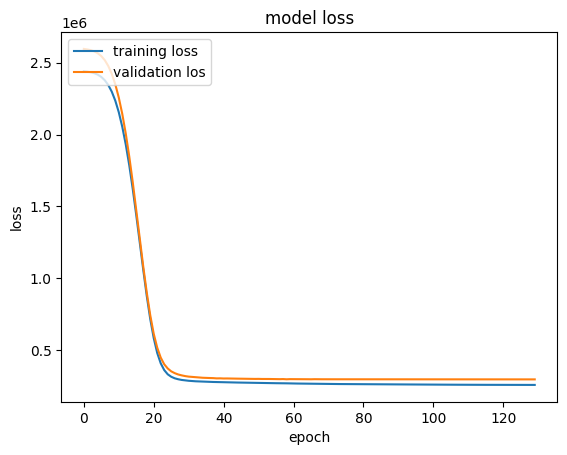

<module 'matplotlib.pyplot' from 'e:\\M2_s1\\all_environements\\ml_env1\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">III. ANN Evaluating</p>

<a class="btn" href="#home">📅 ANN Evaluating</a>

In [16]:
#Prediction
y_pred_train = model.predict(X_train)
y_pred_train

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[1644.9929],
       [1636.4558],
       [1476.2112],
       [1510.2443],
       [1918.3401],
       [1383.0364],
       [1434.695 ],
       [1241.2545],
       [1470.5835],
       [1666.5371],
       [1418.8666],
       [1393.8367],
       [1731.5693],
       [1542.0122],
       [1490.8905],
       [1471.747 ],
       [1510.5808],
       [1654.8633],
       [1397.7366],
       [1427.52  ],
       [1917.2032],
       [1499.7343],
       [1535.3597],
       [1623.3385],
       [1686.6096],
       [1718.5437],
       [1736.2817],
       [1299.7834],
       [1398.37  ],
       [1493.4467],
       [1370.6001],
       [1455.2242],
       [1317.063 ],
       [1612.6335],
       [1456.9839],
       [1691.3625],
       [1411.8018],
       [1434.7102],
       [1428.1793],
       [1358.1588],
       [1706.8665],
       [1606.0577],
       [1473.7236],
       [1204.367 ],
       [1293.7146],
       [1295.155 ],
       [1578.9995],
       [1485.7959],
       [1377.7094],
       [1727.8999],


In [17]:
y_pred_test = model.predict(X_test)
y_pred_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([[1555.7864],
       [1382.6088],
       [1395.2894],
       [1301.2269],
       [1418.3281],
       [1332.3003],
       [1620.0771],
       [1681.562 ],
       [1474.5298],
       [1206.4001],
       [1599.2769],
       [1747.8892],
       [1388.7172],
       [1409.9375],
       [1173.0277],
       [1560.44  ],
       [1347.398 ],
       [1390.4918],
       [1576.7524],
       [1562.8298],
       [1504.281 ],
       [1309.7198],
       [1519.274 ],
       [1688.4368],
       [1290.832 ],
       [1365.3419],
       [1952.385 ],
       [1564.113 ],
       [1203.0742],
       [1620.0552],
       [1757.5823],
       [1802.3828],
       [1545.6863],
       [1508.5931],
       [1380.888 ],
       [1300.8408],
       [1536.7644],
       [1316.6493],
       [1275.1309],
       [1538.241 ],
       [1429.641 ],
       [1417.3357],
       [1711.8708],
       [1732.659 ],
       [1440.4777],
       [1333.9137],
       [1272.9127],
       [1401.3787],
       [1445.0576],
       [1405.9048],


In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
MSE = mean_squared_error(y_test, y_pred_test)
r2_score(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"MSE: {MSE}")
print(f"R2 score: {r2_score(y_train, y_pred_train)}")
print(f"RMSE", RMSE)

MSE: 269164.55844755174
R2 score: -0.011023946097039827
RMSE 518.8107154324704
